In [1]:
 #نصب وابستگی ها فقط یک بار در هر سیستم اجرا شود 

!pip install numpy pandas scikit-learn xgboost shap matplotlib


In [1]:
# -----------------------------
# وارد کردن کتابخانه‌ها
# -----------------------------

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


In [2]:
# -----------------------------
# خواندن دیتافریم از CSV
# -----------------------------

data = pd.read_csv("data.csv")

# ویژگی‌های مورد استفاده
X_cols = [
    'concave points_worst',
    'perimeter_worst',
    'radius_worst',
    'area_worst',
    'concavity_mean',
    'radius_mean',
    'perimeter_mean',
    'area_mean',
    'concavity_worst'

]

X = data[X_cols]

# تبدیل برچسب B / M به عدد
# B → 0  خوش‌خیم
# M → 1  بدخیم

y = data["diagnosis"].map({"B": 0, "M": 1})


In [3]:
# -----------------------------
# تقسیم داده
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)
#تضمین میکند که تقسیم بندی y در دو کلاس برابر باشد     stratify=y,


In [4]:
# -----------------------------
# تعریف Base Models
# -----------------------------

lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced")
)

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

svm = make_pipeline(
    StandardScaler(),
    SVC(probability=True, class_weight="balanced")
)

xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

base_models = [
    ('LR', lr),
    ('RF', rf),
    ('SVM', svm),
    ('XGB', xgb)
]


In [5]:
# -----------------------------
# تعریف Meta Learner
# -----------------------------

meta_model = LogisticRegression(max_iter=2000)

# ساخت Ensemble Stacking
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    stack_method="predict_proba",
    cv=5
)


In [6]:
# -----------------------------
# آموزش مدل ترکیبی
# -----------------------------

stack_model.fit(X_train, y_train)

,estimators,"[('LR', ...), ('RF', ...), ...]"
,final_estimator,LogisticRegre...max_iter=2000)
,cv,5
,stack_method,'predict_proba'
,n_jobs,None
,passthrough,False
,verbose,0
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'


In [7]:
# -----------------------------
# تست مدل
# -----------------------------

# احتمال بدخیمی
y_prob = stack_model.predict_proba(X_test)[:, 1]

# برچسب پیش‌بینی نهایی
y_pred = (y_prob >= 0.5).astype(int)

# معیارهای عملکرد
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

# نمایش جدول نتایج
metrics_table = pd.DataFrame(metrics, index=["Score"]).T
metrics_table


,Score
Accuracy,0.972028
Precision,0.980392
Recall,0.943396
F1-Score,0.961538
ROC-AUC,0.997484


In [8]:
# -----------------------------
#  تشریح تصمیم
# -----------------------------

sample = X_test.iloc[[0]]
probs = stack_model.predict_proba(sample)[0]

label = "Malignant (M)" if probs[1] > 0.5 else "Benign (B)"
confidence = probs[1] if probs[1] > probs[0] else probs[0]

print("\n===== FINAL DECISION =====")
print("Diagnosis:", label)
print("Confidence:", f"{confidence*100:.2f}%")

print("\nFeature values leading to decision:")
display(sample)



===== FINAL DECISION =====
Diagnosis: Malignant (M)
Confidence: 97.30%

Feature values leading to decision:


,concave points_worst,perimeter_worst,radius_worst,area_worst,concavity_mean,radius_mean,perimeter_mean,area_mean,concavity_worst
12,0.1767,151.7,20.96,1332.0,0.2065,19.17,132.4,1123.0,0.3639


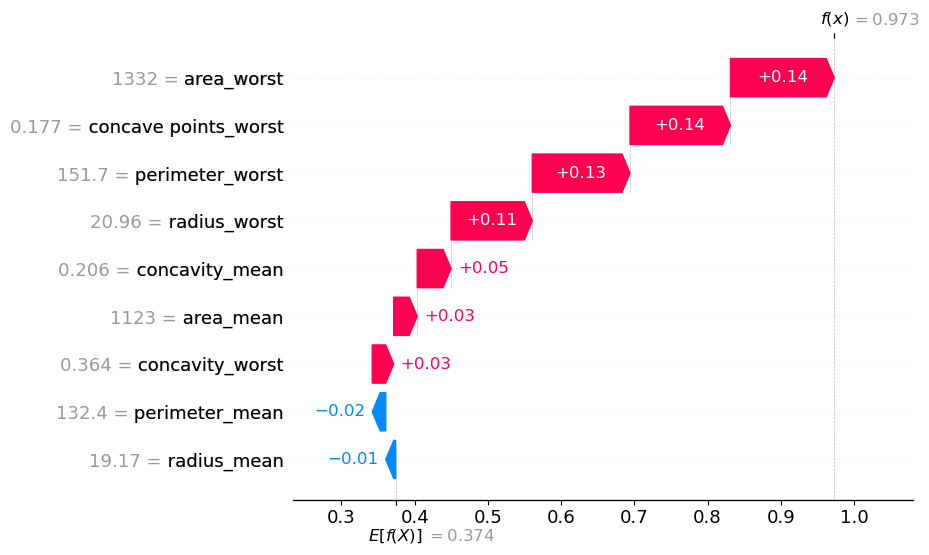

In [10]:
# -----------------------------
# توضیح دلیل تصمیم با SHAP
# -----------------------------

explainer = shap.Explainer(stack_model.predict_proba, X_train)

shap_values = explainer(sample)

# نمودار Waterfall
shap.plots.waterfall(shap_values[0,:,1])


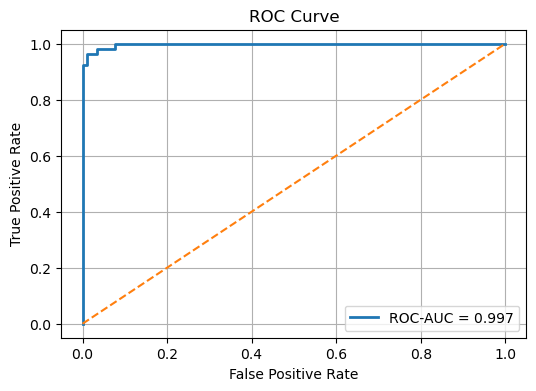

In [11]:
# -----------------------------
# نمودار ROC
# -----------------------------

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, lw=2, label=f"ROC-AUC = {metrics['ROC-AUC']:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


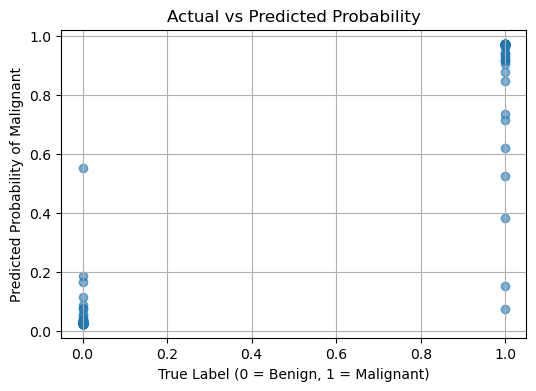

In [12]:
# -----------------------------
# نمودار Actual vs Predicted
# -----------------------------

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_prob, alpha=0.6)
plt.xlabel("True Label (0 = Benign, 1 = Malignant)")
plt.ylabel("Predicted Probability of Malignant")
plt.title("Actual vs Predicted Probability")
plt.grid()
plt.show()


====== Enter Patient Feature Values ======


Radius Worst:  11.8
Perimeter Worst:  76
Area Worst:  420
Concavity Mean:  0.02
Concave Points Worst:  0.01
Radius Mean:  9.8
Perimeter Mean:  62.5
Area Mean:  330
Concavity Worst:  0.03



✅ Patient Data (ordered to match training features):


,concave points_worst,perimeter_worst,radius_worst,area_worst,concavity_mean,radius_mean,perimeter_mean,area_mean,concavity_worst
0,0.01,76.0,11.8,420.0,0.02,9.8,62.5,330.0,0.03


🩺 FINAL DIAGNOSIS
✅ Predicted Diagnosis : BENIGN
✅ Confidence Level     : 97.49 %


,Class,Probability (%)
0,Benign (B),97.488202
1,Malignant (M),2.511798


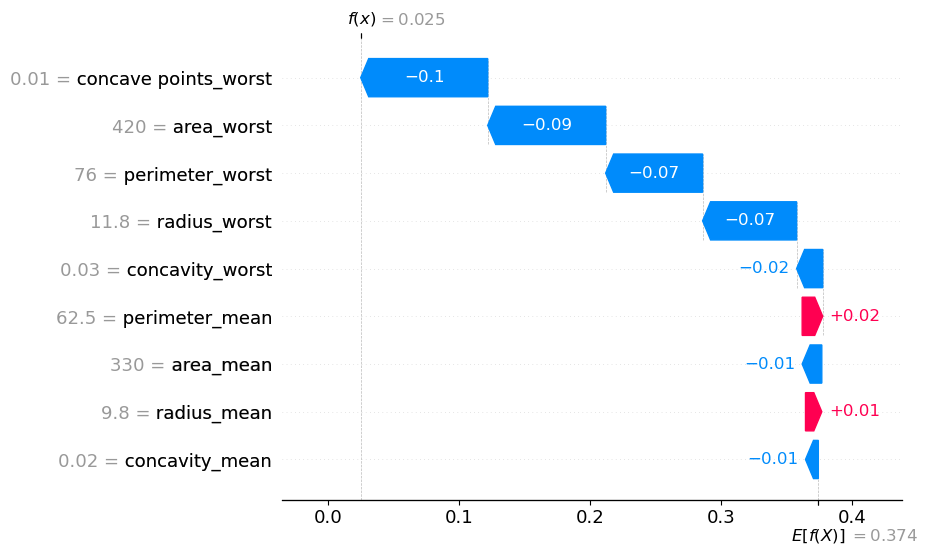


📊 Feature Contribution Table:


,Feature,Feature Value,Impact on Prediction
6,perimeter_mean,62.50,0.015675
5,radius_mean,9.80,0.012430
4,concavity_mean,0.02,-0.009782
7,area_mean,330.00,-0.014978
8,concavity_worst,0.03,-0.019902
2,radius_worst,11.80,-0.071663
1,perimeter_worst,76.00,-0.073915
3,area_worst,420.00,-0.089905
0,concave points_worst,0.01,-0.096809


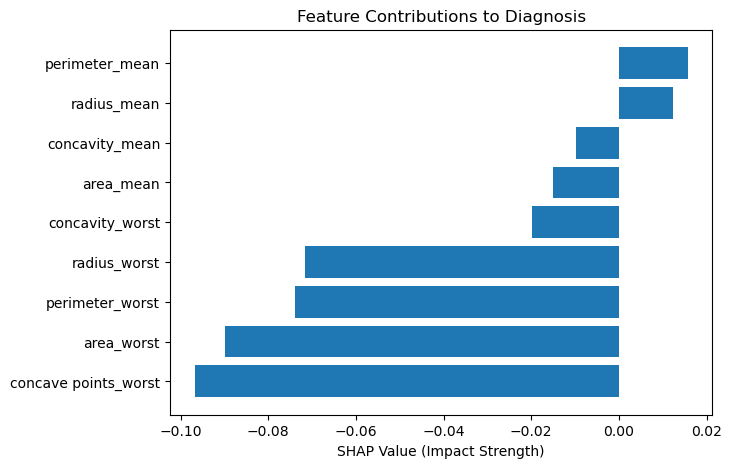

📌 Clinical Interpretation

✅ The strongest contributing biomarker for this diagnosis was:

   👉 perimeter_mean

   Value: 62.5
   Impact Score (SHAP): 0.016



In [14]:
# =============================
# دریافت داده بیمار از پزشک و تحلیل نهایی 
# =============================

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

print("====== Enter Patient Feature Values ======")

# خواندن ورودی‌ها (به صورت float)
radius_worst = float(input("Radius Worst: "))
perimeter_worst = float(input("Perimeter Worst: "))
area_worst = float(input("Area Worst: "))
concavity_mean = float(input("Concavity Mean: "))
concave_points_worst = float(input("Concave Points Worst: "))
radius_mean = float(input("Radius Mean: "))
perimeter_mean = float(input("Perimeter Mean: "))
area_mean = float(input("Area Mean: "))
concavity_worst = float(input("Concavity Worst: "))




# ترتیب و اسم ستون‌ها را دقیقاً از X_train بگیرید (همان‌که مدل روی آن فیت شده)
feature_cols = list(X_train.columns)  # X_train همان X_train که هنگام آموزش ساخته شده است

# ساخت یک سطر دیتا فریم بر پایه ترتیب اصلی ستون‌ها
patient_values = {
    "radius_worst": radius_worst,
    "perimeter_worst": perimeter_worst,
    "area_worst": area_worst,
    "concavity_worst": concavity_worst,
    "concave points_worst": concave_points_worst,

    "radius_mean": radius_mean,
    "perimeter_mean": perimeter_mean,
    "area_mean": area_mean,
    "concavity_mean": concavity_mean
}


# تبدیل به DataFrame و بازچین کردن بر اساس feature_cols (تا ترتیب درست شود)
patient_data = pd.DataFrame([patient_values])
# اطمینان از وجود تمام ستون‌ها و ترتیب صحیح
patient_data = patient_data.reindex(columns=feature_cols)

# اطمینان از نوع عددی (float)
patient_data = patient_data.astype(float)

print("\n✅ Patient Data (ordered to match training features):")
display(patient_data)

# =============================
# 3- پیش‌بینی نهایی مدل (با کنترل خطا)
# =============================
try:
    probs = stack_model.predict_proba(patient_data)[0]
    pred = stack_model.predict(patient_data)[0]
except ValueError as e:
    print("❌ Prediction failed due to feature mismatch or transformer expectations.")
    print("Error message:", str(e))
    print("\n➡️ Debug info:")
    print(" - model expected feature columns (and order):", feature_cols)
    print(" - patient_data columns are         :", list(patient_data.columns))
    raise

# ادامه کد همانند قبل:
diagnosis = "MALIGNANT" if pred==1 else "BENIGN"
confidence = probs[1]*100 if pred==1 else probs[0]*100

print("====================================")
print("🩺 FINAL DIAGNOSIS")
print("====================================")

print(f"✅ Predicted Diagnosis : {diagnosis}")
print(f"✅ Confidence Level     : {confidence:.2f} %")

# جدول احتمالات
prob_table = pd.DataFrame({
    "Class": ["Benign (B)", "Malignant (M)"],
    "Probability (%)": [probs[0]*100, probs[1]*100]
})
display(prob_table)

# ادامه: SHAP، جدول اهمیت، plot ها همان قبل...
explainer = shap.Explainer(stack_model.predict_proba, X_train)
shap_values = explainer(patient_data)
shap.plots.waterfall(shap_values[0, :, 1])

feature_importance = pd.DataFrame({
    "Feature": patient_data.columns,
    "Feature Value": patient_data.iloc[0].values,
    "Impact on Prediction": shap_values.values[0,:,1]
})
feature_importance = feature_importance.sort_values(by="Impact on Prediction", ascending=False)

print("\n📊 Feature Contribution Table:")
display(feature_importance)

plt.figure(figsize=(7,5))
plt.barh(feature_importance["Feature"], feature_importance["Impact on Prediction"])
plt.xlabel("SHAP Value (Impact Strength)")
plt.title("Feature Contributions to Diagnosis")
plt.gca().invert_yaxis()
plt.show()

strongest = feature_importance.iloc[0]
print("====================================")
print("📌 Clinical Interpretation")
print("====================================")
print(f"""
✅ The strongest contributing biomarker for this diagnosis was:

   👉 {strongest['Feature']}

   Value: {strongest['Feature Value']}
   Impact Score (SHAP): {strongest['Impact on Prediction']:.3f}
""")
